# 4.2 — Sparse Autoencoder (SAE) sur les dimensions `alldeep` (NT2 phage)

Approche 2 de l'interprétation (cf. `interpretation.typ`, `@sec:sae`).

On décompose la **partie non triviale** de l'embedding NT2 phage en features latentes
parcimonieuses, plus monosémantiques que les dimensions brutes.

- **Entrée** : les `phage_dims_alldeep` (dimensions *profondes* du NT2 phage, R² < 0.5 face aux k-mers).
- **Split** : entraînement sur les phages de **PredPhi-train**, évaluation sur **PredPhi-test**
  (held-out, phages disjoints — comme les autres notebooks).
- **Modèle** : SAE surcomplet (encodeur `d_in → d_hidden`, ReLU, décodeur lié unit-norm),
  perte = reconstruction (MSE) + L1 sur les activations.
- **Sortie** : activations features keyées par accession phage, sauvées pour l'étape suivante
  (corrélation avec `phage_function_matrix.csv`).

In [1]:
%cd ../..
!pwd

/home/nathan/Documents/sync/HEIG_VD/TB-XAI/FoundedPBI-code
/home/nathan/Documents/sync/HEIG_VD/TB-XAI/FoundedPBI-code


/home/nathan/anaconda3/envs/pbi/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
import os
import numpy as np
import pandas as pd
import h5py
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(0)
np.random.seed(0)
print("device:", device)

device: cuda


## 1. Chargement : embeddings NT2 phage (dims `alldeep`), split PredPhi train / test

In [3]:
from pbi_utils.data_manager import H5pyEmbeddingsManager

EMB_DIR     = "data/embeddings-pbip"
PHAGE_MODEL = "NT2-TruncateStrategy-250M-ov0"   # NT2 phage (Truncate) = modele phage de small2
DIMS_PATH   = "output/pbip/small2/ig30/trivial/phage_dims_alldeep.npy"
NT2_DIM     = 768

dims = np.load(DIMS_PATH)
mgr  = H5pyEmbeddingsManager(EMB_DIR)
print(f"Dims alldeep (profondes) : {len(dims)}  (indices dans le NT2 {NT2_DIM}-dim)")

def load_phage_emb(phage_ids, dims=dims, ndim=NT2_DIM):
    """Charge les embeddings NT2 (dims selectionnees) via le manager standard du projet."""
    ids, vecs = [], []
    for k in phage_ids:
        e = mgr.load_embedding(str(k), PHAGE_MODEL)     # tenseur aplati, ou None si absent
        if e is None or e.numel() != ndim:              # ignore absents / entrees vides
            continue
        ids.append(str(k)); vecs.append(e.numpy())
    return ids, np.stack(vecs)[:, dims]

tr = pd.read_csv("data/perphect-data/predphi/predphi_train_dataset.csv")
te = pd.read_csv("data/perphect-data/predphi/predphi_test_dataset.csv")
ids_tr = sorted(set(tr["phage_id"].astype(str)))
ids_te = sorted(set(te["phage_id"].astype(str)))

ids_train, X_train = load_phage_emb(ids_tr)
ids_test,  X_test  = load_phage_emb(ids_te)
print(f"Train : {X_train.shape[0]} phages | Test : {X_test.shape[0]} phages | dims = {X_train.shape[1]}")
print(f"Phages communs train/test : {len(set(ids_train) & set(ids_test))}")

Dims alldeep (profondes) : 77  (indices dans le NT2 768-dim)
Train : 2831 phages | Test : 618 phages | dims = 77
Phages communs train/test : 0


In [4]:
# Standardisation : on FIT sur le train uniquement, on applique au test (pas de fuite)
scaler   = StandardScaler().fit(X_train)
Xs_train = scaler.transform(X_train).astype(np.float32)
Xs_test  = scaler.transform(X_test).astype(np.float32)
print("variance totale train (standardisee) =", round(float(Xs_train.var(0).sum()), 2))

variance totale train (standardisee) = 77.0


## 2. Définition du SAE

Encodeur `d_in → d_hidden` (ReLU), décodeur à colonnes unit-norm (ré-normalisées après chaque pas),
biais pré-encodeur (*pre-bias*). Perte = MSE de reconstruction + `l1` × |activations|.

In [5]:
class SparseAutoencoder(nn.Module):
    def __init__(self, d_in, d_hidden):
        super().__init__()
        self.pre_bias = nn.Parameter(torch.zeros(d_in))
        self.enc = nn.Linear(d_in, d_hidden)
        self.dec = nn.Linear(d_hidden, d_in, bias=False)
        with torch.no_grad():
            w = torch.randn(d_in, d_hidden)
            w /= w.norm(dim=0, keepdim=True)
            self.dec.weight.copy_(w)
            self.enc.weight.copy_(w.t())
            self.enc.bias.zero_()

    def encode(self, x):
        return torch.relu(self.enc(x - self.pre_bias))

    def decode(self, f):
        return self.dec(f) + self.pre_bias

    def forward(self, x):
        f = self.encode(x)
        return self.decode(f), f

    @torch.no_grad()
    def normalize_decoder(self):
        self.dec.weight.div_(self.dec.weight.norm(dim=0, keepdim=True) + 1e-8)

In [6]:
def _metrics(sae, X, var_tot, l1):
    """MSE, penalite L1, L0 moyen, variance expliquee sur un tenseur X."""
    with torch.no_grad():
        xhat, f = sae(X)
        mse = float(((xhat - X) ** 2).sum(1).mean())
        l1v = float(f.abs().sum(1).mean())
        l0  = float((f > 1e-6).float().sum(1).mean())
    return mse, l1v, l0, 1 - mse / var_tot


def train_sae(Xs, d_hidden, l1, Xs_val=None, lr=1e-3, epochs=300, batch=256,
              device=device, log_every=25):
    d_in = Xs.shape[1]
    sae  = SparseAutoencoder(d_in, d_hidden).to(device)
    opt  = torch.optim.Adam(sae.parameters(), lr=lr)
    Xt   = torch.tensor(Xs, device=device)
    Xv   = torch.tensor(Xs_val, device=device) if Xs_val is not None else None
    n    = Xt.shape[0]
    var_tr = float(((Xt - Xt.mean(0)) ** 2).sum(1).mean())
    var_va = float(((Xv - Xv.mean(0)) ** 2).sum(1).mean()) if Xv is not None else None
    hist = []
    for ep in range(epochs):
        perm = torch.randperm(n, device=device)
        for i in range(0, n, batch):
            idx = perm[i:i + batch]
            xb  = Xt[idx]
            xhat, f = sae(xb)
            mse = ((xhat - xb) ** 2).sum(1).mean()
            l1p = f.abs().sum(1).mean()
            loss = mse + l1 * l1p
            opt.zero_grad(); loss.backward(); opt.step()
            sae.normalize_decoder()
        if ep % log_every == 0 or ep == epochs - 1:
            mse_t, l1_t, l0_t, ve_t = _metrics(sae, Xt, var_tr, l1)
            rec = {"epoch": ep, "loss": mse_t + l1 * l1_t, "mse": mse_t, "l1": l1_t,
                   "var_expl": ve_t, "l0": l0_t}
            msg = (f"  ep {ep + 1:4d} | loss={rec['loss']:.3f} (mse={mse_t:.3f} + {l1:g}*l1={l1*l1_t:.3f}) "
                   f"| var expl train={ve_t:.3f}")
            if Xv is not None:
                mse_v, _, l0_v, ve_v = _metrics(sae, Xv, var_va, l1)
                rec.update({"var_expl_test": ve_v, "l0_test": l0_v, "mse_test": mse_v})
                msg += f" / test={ve_v:.3f}"
            msg += f" | L0={l0_t:.1f}/{d_hidden}"
            hist.append(rec); print(msg)
    return sae, pd.DataFrame(hist)

## 3. Entraînement (sur PredPhi-train, suivi sur PredPhi-test)

`d_hidden` surcomplet (expansion × nb de dims). `l1` règle le compromis reconstruction / parcimonie.

In [7]:
EXPANSION = 18
L1        = 0.1
EPOCHS    = 500

d_hidden = EXPANSION * Xs_train.shape[1]
print(f"SAE : {Xs_train.shape[1]} -> {d_hidden} features (expansion x{EXPANSION}), l1={L1}")
sae, hist = train_sae(Xs_train, d_hidden=d_hidden, l1=L1, Xs_val=Xs_test, epochs=EPOCHS)

SAE : 77 -> 1386 features (expansion x18), l1=0.1
  ep    1 | loss=2294.528 (mse=2253.800 + 0.1*l1=40.728) | var expl train=-28.270 / test=-38.070 | L0=690.6/1386
  ep   26 | loss=31.350 (mse=23.540 + 0.1*l1=7.809) | var expl train=0.694 / test=0.243 | L0=304.8/1386
  ep   51 | loss=13.043 (mse=7.722 + 0.1*l1=5.321) | var expl train=0.900 / test=0.699 | L0=192.5/1386
  ep   76 | loss=9.284 (mse=4.576 + 0.1*l1=4.708) | var expl train=0.941 / test=0.796 | L0=163.8/1386
  ep  101 | loss=7.538 (mse=3.186 + 0.1*l1=4.352) | var expl train=0.959 / test=0.840 | L0=150.4/1386
  ep  126 | loss=6.501 (mse=2.421 + 0.1*l1=4.080) | var expl train=0.969 / test=0.864 | L0=142.4/1386
  ep  151 | loss=5.800 (mse=1.942 + 0.1*l1=3.859) | var expl train=0.975 / test=0.882 | L0=136.7/1386
  ep  176 | loss=5.289 (mse=1.623 + 0.1*l1=3.666) | var expl train=0.979 / test=0.895 | L0=132.6/1386
  ep  201 | loss=4.889 (mse=1.376 + 0.1*l1=3.513) | var expl train=0.982 / test=0.904 | L0=129.7/1386
  ep  226 | loss=4

## 4. Diagnostics

Reconstruction rapportée sur **PredPhi-test** (held-out). L'écart train/test mesure
l'éventuel sur-apprentissage. Fréquence d'activation et features mortes calculées sur le train.

Variance expliquee | train=0.993  test=0.938
L0 moyen (test)    : 147.8 / 1386 features actives par phage
Features mortes     : 1 / 1386 (0%)


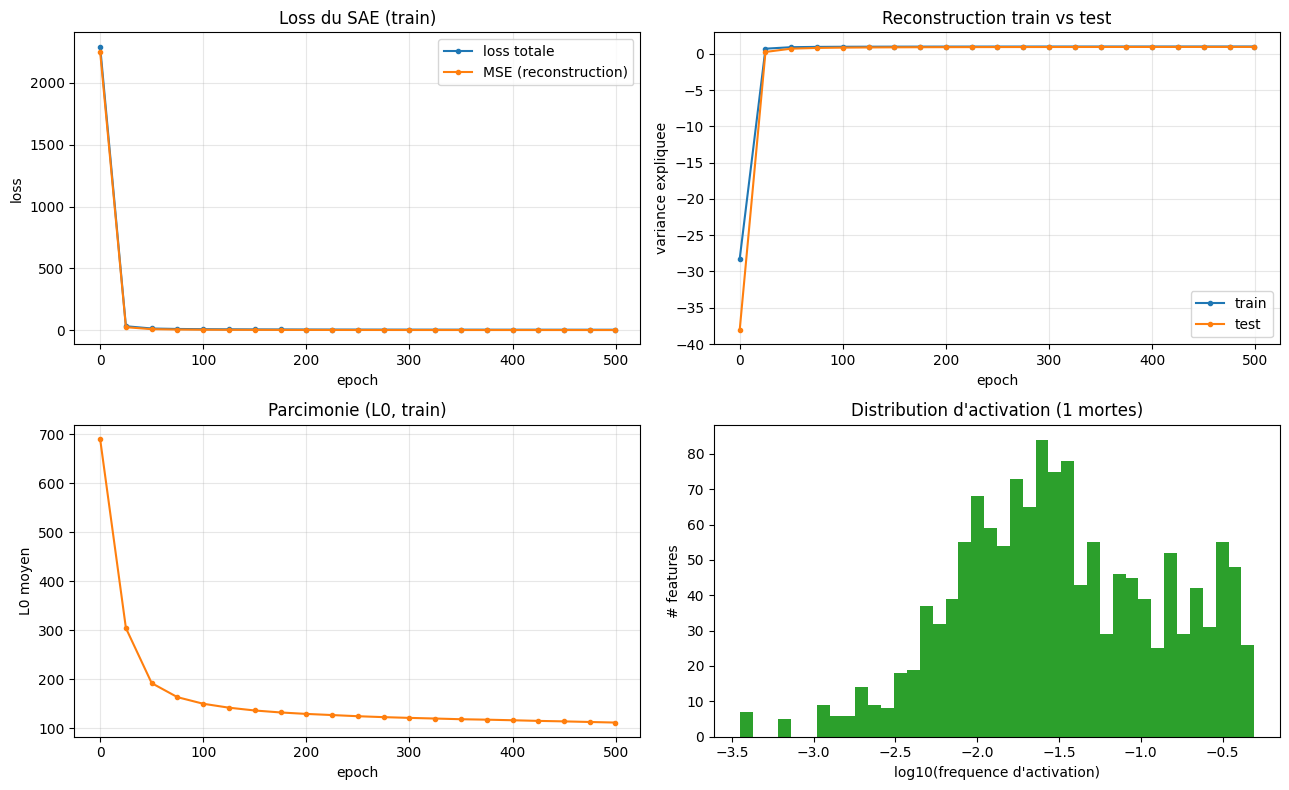

In [8]:
def recon(Xs):
    """Reconstruction et activations (sans gradient)."""
    with torch.no_grad():
        xhat, f = sae(torch.tensor(Xs, device=device))
    return xhat.cpu().numpy(), f.cpu().numpy()

Xhat_train, F_train = recon(Xs_train)
Xhat_test,  F_test  = recon(Xs_test)

def var_expl(Xs, Xhat):
    var_tot = ((Xs - Xs.mean(0)) ** 2).sum(1).mean()
    return 1 - ((Xs - Xhat) ** 2).sum(1).mean() / var_tot

ve_train = var_expl(Xs_train, Xhat_train)
ve_test  = var_expl(Xs_test,  Xhat_test)

fire_freq = (F_train > 1e-6).mean(0)        # frequence d'activation par feature (sur le train)
dead = int((fire_freq == 0).sum())
l0_test = float((F_test > 1e-6).sum(1).mean())

print(f"Variance expliquee | train={ve_train:.3f}  test={ve_test:.3f}")
print(f"L0 moyen (test)    : {l0_test:.1f} / {F_train.shape[1]} features actives par phage")
print(f"Features mortes     : {dead} / {F_train.shape[1]} ({100*dead/F_train.shape[1]:.0f}%)")

fig, ax = plt.subplots(2, 2, figsize=(13, 8))
ax[0, 0].plot(hist["epoch"], hist["loss"], "-o", ms=3, label="loss totale")
ax[0, 0].plot(hist["epoch"], hist["mse"],  "-o", ms=3, label="MSE (reconstruction)")
ax[0, 0].set(xlabel="epoch", ylabel="loss", title="Loss du SAE (train)")
ax[0, 0].legend(); ax[0, 0].grid(alpha=.3)
ax[0, 1].plot(hist["epoch"], hist["var_expl"],      "-o", ms=3, label="train")
if "var_expl_test" in hist:
    ax[0, 1].plot(hist["epoch"], hist["var_expl_test"], "-o", ms=3, label="test")
ax[0, 1].set(xlabel="epoch", ylabel="variance expliquee", title="Reconstruction train vs test")
ax[0, 1].legend(); ax[0, 1].grid(alpha=.3)
ax[1, 0].plot(hist["epoch"], hist["l0"], "-o", ms=3, color="C1")
ax[1, 0].set(xlabel="epoch", ylabel="L0 moyen", title="Parcimonie (L0, train)")
ax[1, 0].grid(alpha=.3)
ax[1, 1].hist(np.log10(fire_freq[fire_freq > 0] + 1e-12), bins=40, color="C2")
ax[1, 1].set(xlabel="log10(frequence d'activation)", ylabel="# features",
             title=f"Distribution d'activation ({dead} mortes)")
plt.tight_layout(); plt.show()

## 5. Sauvegarde

Activations features pour tous les phages PredPhi (train ∪ test), keyées par accession,
avec une colonne `split`. Interface pour la corrélation avec `phage_function_matrix.csv`.

In [9]:
OUT = "output/pbip/small2/ig30/sae_nt2_alldeep"
os.makedirs(OUT, exist_ok=True)

F_all  = np.vstack([F_train, F_test])
ids_all = ids_train + ids_test
split   = ["train"] * len(ids_train) + ["test"] * len(ids_test)
feat_df = pd.DataFrame(F_all, index=pd.Index(ids_all, name="phage_id"),
                       columns=[f"f{j}" for j in range(F_all.shape[1])])
feat_df.insert(0, "split", split)
feat_df.to_csv(os.path.join(OUT, "feature_activations.csv"))

torch.save({"state_dict": sae.state_dict(),
            "d_in": Xs_train.shape[1], "d_hidden": d_hidden,
            "expansion": EXPANSION, "l1": L1, "epochs": EPOCHS},
           os.path.join(OUT, "sae.pth"))
np.savez(os.path.join(OUT, "scaler.npz"), mean=scaler.mean_, scale=scaler.scale_, dims=dims)

print("Sauve dans", OUT)
print(" - feature_activations.csv :", feat_df.shape, "(train+test)")
print(" - sae.pth, scaler.npz")
feat_df.iloc[:6, :24]

Sauve dans output/pbip/small2/ig30/sae_nt2_alldeep
 - feature_activations.csv : (3449, 1387) (train+test)
 - sae.pth, scaler.npz


,split,f0,f1,f2,f3,f4,f5,f6,f7,f8,...,f13,f14,f15,f16,f17,f18,f19,f20,f21,f22
phage_id,,,,,,,,,,,,,,,,,,,,,
GQ303259,train,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.053384,0.0
GQ303261,train,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
GQ303262,train,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
GQ303264,train,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
GQ303265,train,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
GQ303266,train,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0


## 6. Caractérisation des latents par F1-score (protocole *Decode-gLM*)

On caractérise chaque latent du SAE en le confrontant aux annotations biologiques (pharokka), avec la
métrique de **Decode-gLM** (Maiwald et al., 2025), qui applique exactement cette approche aux latents de
SAE sur Nucleotide Transformer :

- pour chaque couple (latent, annotation), le **seuil d'activation** est choisi sur le **train**
  (rôle validation) de façon à maximiser le F1 ;
- le F1 est ensuite mesuré sur le **test** (phages held-out, disjoints du train) ;
- un latent est dit **interprétable** s'il atteint **F1 ≥ 0.20** pour au moins une annotation.

Le F1 mesure la *spécificité* du détecteur (pas seulement la séparation) et le train/test protège de la
« malédiction du gagnant » : choisir la meilleure annotation parmi des milliers sur le train, puis
vérifier sur le test. C'est cette protection qui permet une borne de support **permissive** (`≥ 10`) —
les annotations trop rares ne se répliquent tout simplement pas sur le test. La borne haute (`40 %`)
écarte les labels quasi-universels, dont le F1 serait trivialement élevé.

In [10]:
import re

# === Metrique F1 facon Decode-gLM (Maiwald et al., 2025) ===
# Pour chaque (latent, annotation) : le seuil d'activation est choisi sur le TRAIN (role validation)
# pour maximiser le F1, puis le F1 est mesure sur le TEST (phages held-out, disjoints). Un latent est
# "interpretable" si son meilleur F1_test >= 0.20. Le F1 penalise les features fourre-tout (haute
# separation mais faible precision) et le train/test protege de la malediction du gagnant.
F1_INTERP = 0.20      # barre "interpretable" (Decode-gLM)
QUALITY   = 0.50      # barre "bien detecte" : concept avec au moins un detecteur solide
QLEVELS = [0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99]   # seuils candidats = quantiles d'activation par latent

# --- Chargement : activations SAE (avec split) + annotations biologiques (pharokka) ---
feat = pd.read_csv("output/pbip/small2/ig30/sae_nt2_alldeep/feature_activations.csv", index_col="phage_id")
ann  = pd.read_csv("analysis/TB/annotations/pharokka/phage_function_matrix.csv")
ann["phage_id"] = ann["phage_id"].astype(str)
ann = ann.set_index("phage_id")
common = feat.index.intersection(ann.index)
feat, ann = feat.loc[common], ann.loc[common]

# Borne basse permissive : le train/test ecarte tout seul les annotations trop rares (elles ne se
# repliquent pas sur le test). Borne haute : evite les labels quasi-universels (F1 trivialement eleve).
SUP_MIN, SUP_MAX = 10, int(0.40 * len(common))

split = feat["split"].values
tr, te = split == "train", split == "test"
F = feat[[c for c in feat.columns if re.match(r"^f\d+$", str(c))]]
F = F.loc[:, (F.values[tr] > 1e-6).mean(0) > 0.01]            # features vivantes (sur le train)
A = (ann > 0).astype(int); A = A.loc[:, A.std() > 0]
support = A.sum(); keep = (support >= SUP_MIN) & (support <= SUP_MAX)
A, support = A.loc[:, keep], support[keep]
print(f"Phages : {len(common)} | latents vivants : {F.shape[1]} | "
      f"annotations (support in [{SUP_MIN}, {SUP_MAX}]) : {A.shape[1]}")

Ftr, Fte = F.values[tr], F.values[te]
Atr, Ate = A.values[tr].astype(float), A.values[te].astype(float)
pos_tr, pos_te = Atr.sum(0), Ate.sum(0)
L, C = F.shape[1], A.shape[1]

best_tr = np.zeros((L, C)); f1te_at_best = np.zeros((L, C))
for q in QLEVELS:                                   # seuil par latent = q-quantile de ses activations (train)
    thr = np.quantile(Ftr, q, axis=0)
    Btr, Bte = (Ftr > thr).astype(float), (Fte > thr).astype(float)
    tp = Btr.T @ Atr; P = tp / np.maximum(Btr.sum(0)[:, None], 1); R = tp / np.maximum(pos_tr[None, :], 1)
    f1tr = 2 * P * R / np.maximum(P + R, 1e-9)
    tp2 = Bte.T @ Ate; P2 = tp2 / np.maximum(Bte.sum(0)[:, None], 1); R2 = tp2 / np.maximum(pos_te[None, :], 1)
    f1te = 2 * P2 * R2 / np.maximum(P2 + R2, 1e-9)
    upd = f1tr > best_tr                              # on garde le seuil qui maximise le F1 TRAIN
    best_tr = np.where(upd, f1tr, best_tr); f1te_at_best = np.where(upd, f1te, f1te_at_best)

F1tr = pd.DataFrame(best_tr, index=F.columns, columns=A.columns)
F1te = pd.DataFrame(f1te_at_best, index=F.columns, columns=A.columns)

# --- Vue PAR LATENT : meilleure annotation choisie sur le TRAIN, F1 reporte sur le TEST ---
# F1_test >> F1_train = coup de chance sur le petit test set (a ne pas prendre pour une decouverte).
rows = []
for j in F1tr.index:
    c = F1tr.loc[j].idxmax()
    rows.append({"feature": j, "annotation": c, "F1_test": round(F1te.loc[j, c], 3),
                 "F1_train": round(F1tr.loc[j, c], 3), "support": int(support[c])})
best_f1_per_feature = pd.DataFrame(rows).sort_values("F1_test", ascending=False).reset_index(drop=True)

# --- Vue PAR CONCEPT : le meilleur detecteur de chaque concept ---
# Le groupby dedoublonne deja : les concepts listes sont tous DIFFERENTS les uns des autres.
# La colonne n_latents dit par combien de features chaque concept est capte (1 = pas de redondance).
interp = best_f1_per_feature[best_f1_per_feature["F1_test"] >= F1_INTERP]
best_f1_per_concept = (interp.groupby("annotation")
                       .agg(F1_test=("F1_test", "max"),
                            n_latents=("feature", "size"),
                            support=("support", "first"))
                       .sort_values("F1_test", ascending=False)
                       .reset_index())

good = best_f1_per_concept[best_f1_per_concept["F1_test"] >= QUALITY]
mono = good[good["n_latents"] == 1]        # capte par UNE SEULE feature (pas de doublon)

print(f"latents interpretables (F1>={F1_INTERP})                : {len(interp)}/{L}")
print(f"concepts differents detectes (F1>={F1_INTERP})          : {len(best_f1_per_concept)}")
print(f"concepts differents BIEN detectes (F1>={QUALITY})       : {len(good)}")
print(f"redondance moyenne : {len(interp)/max(len(best_f1_per_concept),1):.1f} latents par concept")
best_f1_per_concept.head(50)

Phages : 3449 | latents vivants : 1090 | annotations (support in [10, 1379]) : 950
latents interpretables (F1>=0.2)                : 180/1090
concepts differents detectes (F1>=0.2)          : 43
concepts differents BIEN detectes (F1>=0.5)       : 10
redondance moyenne : 4.2 latents par concept


,annotation,F1_test,n_latents,support
0,func_head_maturation_protease,0.694,27,1315
1,func_thioredoxin_domain,0.647,1,43
2,func_head_scaffolding_protein,0.592,3,938
3,func_head_tail_adaptor,0.587,1,778
4,phrog_233,0.578,2,262
5,func_tail_assembly_chaperone,0.546,2,940
6,func_tail_length_tape_measure_protein,0.546,3,848
7,phrog_16241,0.526,1,13
8,connector,0.518,27,1316
9,func_lsr2_like_dna_bridging_protein,0.500,4,17
